# Trader Performance vs Market Sentiment Analysis

## Objective
The objective of this project is to analyze how Bitcoin market sentiment (Fear and Greed) affects trader performance and behavior. By combining sentiment data with historical trade data, the goal is to identify patterns in profitability, trading activity, and risk-taking behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

## Dataset Overview

In [3]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [4]:
print("Missing values in sentiment:")
print(sentiment.isnull().sum())

print("\nMissing values in trades:")
print(trades.isnull().sum())

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [5]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Column Inspection

In [8]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Data Cleaning and Preparation

## Converting date

In [9]:
# FIX DATE FORMAT (important)
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

## Removing duplicates

In [10]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

## Remove important missing values

In [11]:
trades = trades.dropna(subset=['Closed PnL', 'Size USD', 'date'])

## Merge both datasets

In [13]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

## Additional Trading Metrics

In [14]:
daily_trades = merged.groupby('date').size().reset_index(name='trade_count')
daily_trades.head()

,date,trade_count
0,2023-01-05,3
1,2023-05-12,9
2,2024-01-01,18
3,2024-01-02,6
4,2024-01-03,137


In [15]:
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Closed PnL
0,2023-01-05,0.000000
1,2023-05-12,0.000000
2,2024-01-01,-129.531460
3,2024-01-02,0.000000
4,2024-01-03,8244.241409


In [16]:
pd.crosstab(merged['classification'], merged['Direction'], normalize='index') * 100

Direction,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Short > Long,Spot Dust Conversion
classification,,,,,,,,,
Extreme Fear,3.310404,28.933792,4.557180,0.000000,42.304385,18.959587,1.848667,0.042992,0.042992
Extreme Greed,8.343711,10.781000,11.385874,0.017790,9.802526,20.708059,38.783135,0.017790,0.160114
Fear,7.231956,19.410195,19.842815,0.036052,25.582234,22.186171,5.559161,0.028841,0.122576
Greed,13.407722,23.653914,18.269571,0.106270,16.099894,18.809777,9.466879,0.106270,0.079702
Neutral,13.679245,16.509434,13.788099,0.000000,9.542816,16.001451,30.333817,0.000000,0.145138


In [17]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [18]:
merged['classification'].isnull().sum()

np.int64(0)

In [19]:
merged['win'] = np.where(merged['Closed PnL'] > 0, 1, 0)

## Performance Analysis

### Creating performance table

In [20]:
performance = merged.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('win', 'mean'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

performance['win_rate'] = performance['win_rate'] * 100

performance

,classification,total_pnl,avg_pnl,win_rate,avg_trade_size
0,Extreme Fear,4.399937e+03,1.891632,29.277730,4118.761840
1,Extreme Greed,1.156894e+06,205.816345,55.328233,3242.085086
2,Fear,1.779226e+06,128.287950,38.178672,5744.782685
3,Greed,6.096325e+05,53.988003,43.570670,5051.878829
4,Neutral,7.465674e+04,27.088803,49.492017,4332.202906


## Creating behavior table

In [21]:
behavior = merged.groupby('classification').agg(
    trades_count=('Account', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    avg_fee=('Fee', 'mean'),
    avg_start_position=('Start Position', 'mean')
).reset_index()

behavior

,classification,trades_count,avg_size_usd,avg_fee,avg_start_position
0,Extreme Fear,2326,4118.761840,0.686479,21902.797505
1,Extreme Greed,5621,3242.085086,0.835794,24593.241160
2,Fear,13869,5744.782685,1.131521,8146.358518
3,Greed,11292,5051.878829,1.092947,37276.787811
4,Neutral,2756,4332.202906,0.922389,89199.587406


## Key Insights

1. It looks like traders do best during Extreme Greed. Both the win rate and average PnL are higher, so trades are more successful when the market sentiment is very positive.

2. In Fear conditions, total PnL is actually the highest, but the win rate is lower. This suggests that traders are taking larger trades, which increases overall profit but also makes results less consistent.

3. Extreme Fear seems to be the worst situation for trading. The win rate is very low and profits are also minimal, which shows that traders struggle during very negative sentiment.

4. I also noticed that trade sizes are bigger during Fear compared to Greed. This indicates that traders take more risk when the market is uncertain.

## Trader Segmentation

In [22]:
account_freq = merged.groupby('Account').size().reset_index(name='trade_count')

freq_median = account_freq['trade_count'].median()

account_freq['frequency_segment'] = np.where(
    account_freq['trade_count'] >= freq_median,
    'Frequent Trader',
    'Infrequent Trader'
)

merged = merged.merge(account_freq[['Account', 'frequency_segment']], on='Account', how='left')

In [23]:
freq_segment_perf = merged.groupby('frequency_segment').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('win', 'mean')
).reset_index()

freq_segment_perf['win_rate'] *= 100
freq_segment_perf

,frequency_segment,total_pnl,avg_pnl,win_rate
0,Frequent Trader,3.319259e+06,99.091235,43.538227
1,Infrequent Trader,3.055494e+05,129.087187,33.206591


In [24]:
size_median = merged['Size USD'].median()

merged['size_segment'] = np.where(
    merged['Size USD'] >= size_median,
    'High Size Trader',
    'Low Size Trader'
)

In [25]:
size_segment_perf = merged.groupby('size_segment').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('win', 'mean')
).reset_index()

size_segment_perf['win_rate'] *= 100
size_segment_perf

,size_segment,total_pnl,avg_pnl,win_rate
0,High Size Trader,3.472174e+06,193.630063,41.155476
1,Low Size Trader,1.526342e+05,8.511833,44.557216


## Strategy Recommendations

1. It may be better to trade more actively during Extreme Greed periods, since both win rate and average PnL are stronger in positive market sentiment.

2. During Fear periods, traders should be more careful with position size, because total profit is high but results are less consistent and trade sizes are larger.

3. Extreme Fear appears to be the weakest condition for trading, so reducing aggressive exposure during these periods could help control risk.

# Visual Analysis

### Total PnL by Market Sentiment

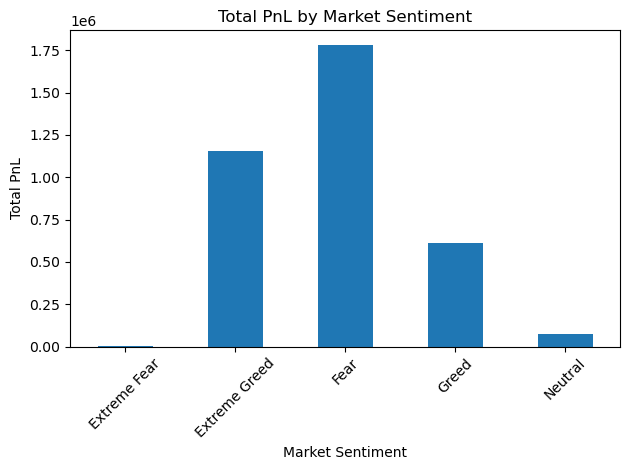

In [26]:
performance.plot(x='classification', y='total_pnl', kind='bar', legend=False)
plt.title("Total PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows how total profit and loss varies across different market sentiment conditions. It helps understand during which sentiment traders generate the most overall profit.

### Win Rate by Market Sentiment

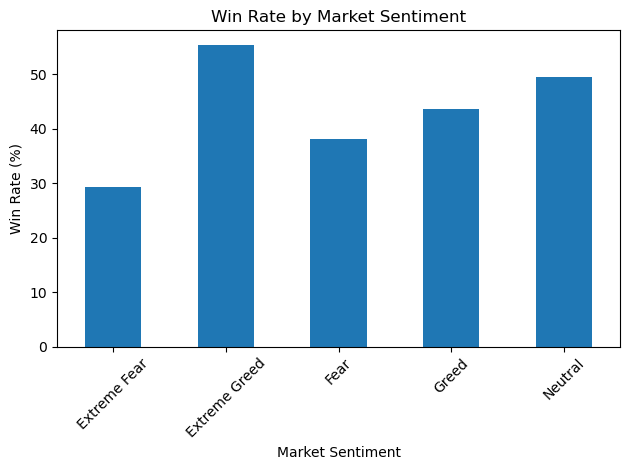

In [27]:
performance.plot(x='classification', y='win_rate', kind='bar', legend=False)
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the percentage of winning trades under each sentiment category. It gives a clearer idea of trading success beyond just total profit.

### Average Trade Size by Market Sentiment

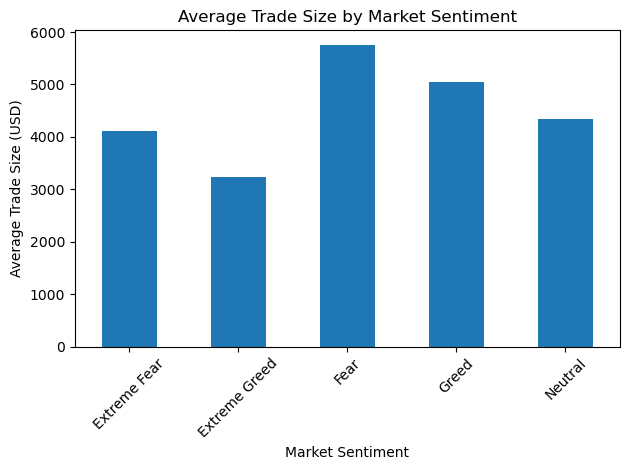

In [28]:
performance.plot(x='classification', y='avg_trade_size', kind='bar', legend=False)
plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows how the average trade size changes across sentiment categories. It helps understand how trader risk-taking behavior varies with market conditions.

### Number of Trades by Market Sentiment

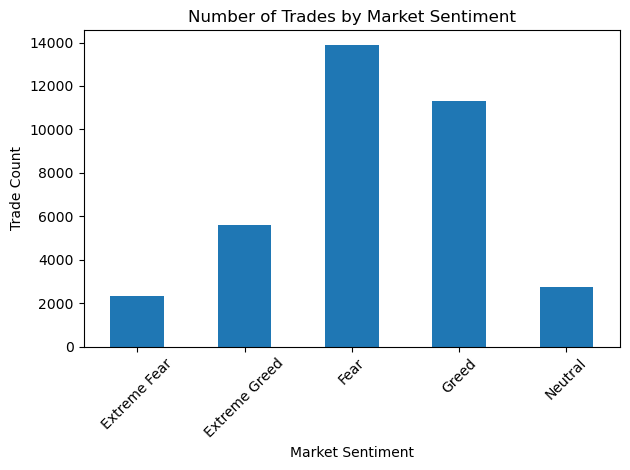

In [29]:
behavior.plot(x='classification', y='trades_count', kind='bar', legend=False)
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the number of trades executed under each sentiment condition. It helps identify whether traders are more active during certain market moods.

## Methodology

- Loaded sentiment and trader datasets
- Cleaned missing values and duplicates
- Converted timestamps into consistent date format
- Merged datasets using date as the key
- Calculated key performance metrics like PnL and win rate
- Analyzed trader behavior across different sentiment categories
- Visualized results and derived insights

## Conclusion

This analysis shows that market sentiment has a clear impact on trader performance and behavior. Traders tend to perform better during positive sentiment conditions, while negative sentiment leads to more risk-taking and inconsistent results. These findings can help in making more informed trading decisions.